In [1]:
import math
import numpy as np
import torch
import matplotlib.pyplot as plt

import os, sys
os.chdir('..')

from sazz.samplers.StickyAutomaticBoomerangSampler import StickyAutomaticBoomerangSampler
from sazz.utils.sampling import resample_pdmp_path_sticky
from sazz.models.sticky_smoke_test import make_spike_and_slab, plot_sticky_marginals, print_sparsity_summary

Sticky Boomerang: 100%|██████████| 100000/100000 [00:33<00:00, 2947.51skel/s, t=44673.856]



=== Sampler Diagnostics ===
Total gradient evals  : 499995
Grad evals / skeleton : 5.0
Mean sparsity (frac frozen): 0.649
Max simultaneous frozen    : 10 / 100000

=== Thinning ===
Accepted bounces : 0

=== Event breakdown ===
  freeze    : 47797 events, mean horizon=0.4713
  thaw      : 47790 events, mean horizon=0.4236
  refresh   :  4412 events, mean horizon=0.0000
  no_event  :  4412 events, mean horizon=0.4314

=== Timing ===
Mean wall-sec / iter : 0.000315
Total wall-sec       : 32.91

Simulation time reached: 44673.8556


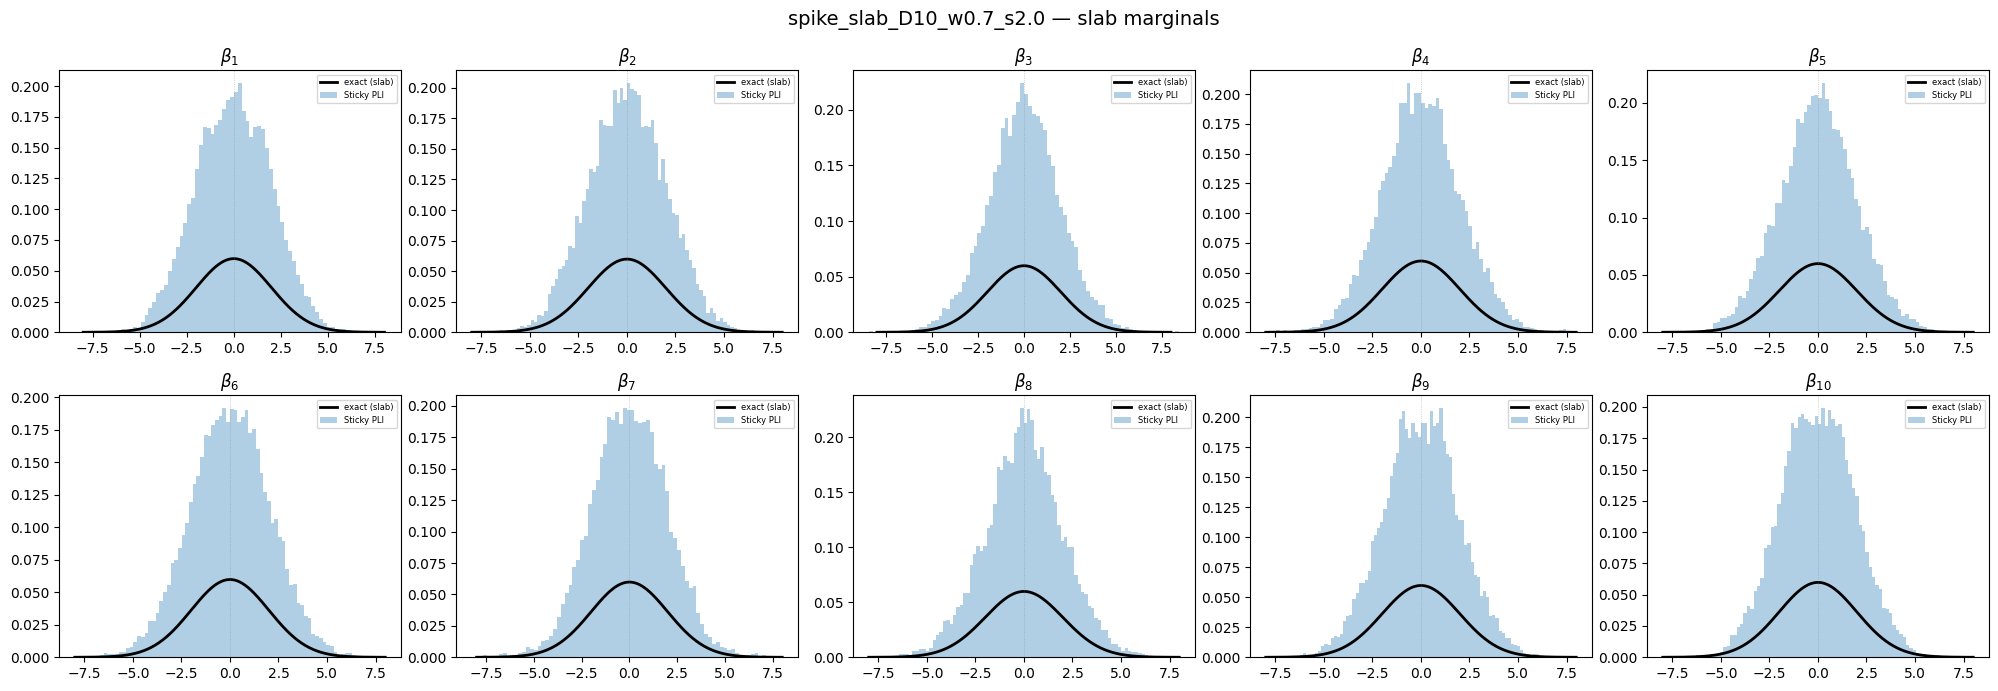

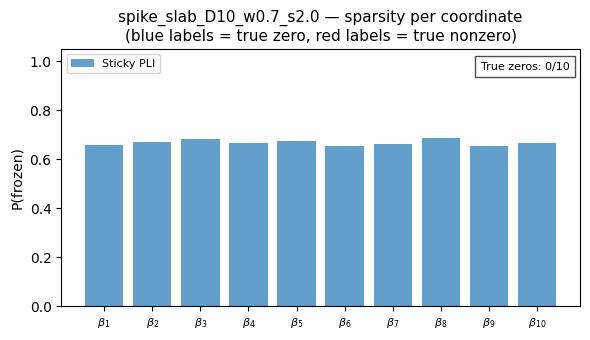

In [2]:
N_SKELETON = 100_000
N_RESAMPLE = 100_000
target = make_spike_and_slab(D=10, w_spike=0.7, sigma_slab=2.0)

# sampler_brent = StickyAutomaticBoomerangSampler(
#     grad_target=target.grad_target, D=target.D,
#     kappa=0.1, thinning="brent", refresh_rate=0.1,
# )

# sampler_brent.preprocess(x_ref=target.x_ref, Sigma_inv=target.Sigma_inv)
# result_brent = sampler_brent.sample(N=N_SKELETON)

# samples_brent = resample_pdmp_path_sticky(
#     result_brent["positions"].cpu().numpy(),
#     result_brent["velocities"].cpu().numpy(),
#     result_brent["times"].cpu().numpy(),
#     target.x_ref.cpu().numpy(),
#     N_resample=N_RESAMPLE,
# )


sampler_pli = StickyAutomaticBoomerangSampler(
    grad_target=target.grad_target, D=target.D,
    kappa=0.1, thinning="pli", refresh_rate=0.1,
)

sampler_pli.preprocess(x_ref=target.x_ref, Sigma_inv=target.Sigma_inv)
result_pli = sampler_pli.sample(N=N_SKELETON)

samples_pli = resample_pdmp_path_sticky(
    result_pli["positions"].cpu().numpy(),
    result_pli["velocities"].cpu().numpy(),
    result_pli["times"].cpu().numpy(),
    target.x_ref.cpu().numpy(),
    N_resample=N_RESAMPLE,
)


#plot_sticky_marginals(target, {"Sticky Brent": samples_brent, "Sticky PLI": samples_pli})
plot_sticky_marginals(target, {"Sticky PLI": samples_pli})


In [3]:
#print_sparsity_summary(target, {"Sticky Brent": samples_brent, "Sticky PLI": samples_pli})
print_sparsity_summary(target, {"Sticky PLI": samples_pli})


Sparsity summary: spike_slab_D10_w0.7_s2.0

  Sticky PLI:
    coord        P(0)
    --------------------
    0           0.657
    1           0.671
    2           0.681
    3           0.666
    4           0.674
    5           0.653
    6           0.661
    7           0.688
    8           0.655
    9           0.665

    Overall sparsity: 0.667


Sticky Boomerang: 100%|██████████| 100000/100000 [00:48<00:00, 2076.70skel/s, t=859209.503]



=== Sampler Diagnostics ===
Total gradient evals  : 499995
Grad evals / skeleton : 5.0
Mean sparsity (frac frozen): 0.746
Max simultaneous frozen    : 15 / 100000

=== Thinning ===
Accepted bounces : 0

=== Event breakdown ===
  freeze    :  7223 events, mean horizon=2.5743
  thaw      :  7208 events, mean horizon=9.0612
  refresh   : 85568 events, mean horizon=0.0000
  no_event  : 85568 events, mean horizon=9.0607

=== Timing ===
Mean wall-sec / iter : 0.000186
Total wall-sec       : 34.53

Simulation time reached: 859209.5030


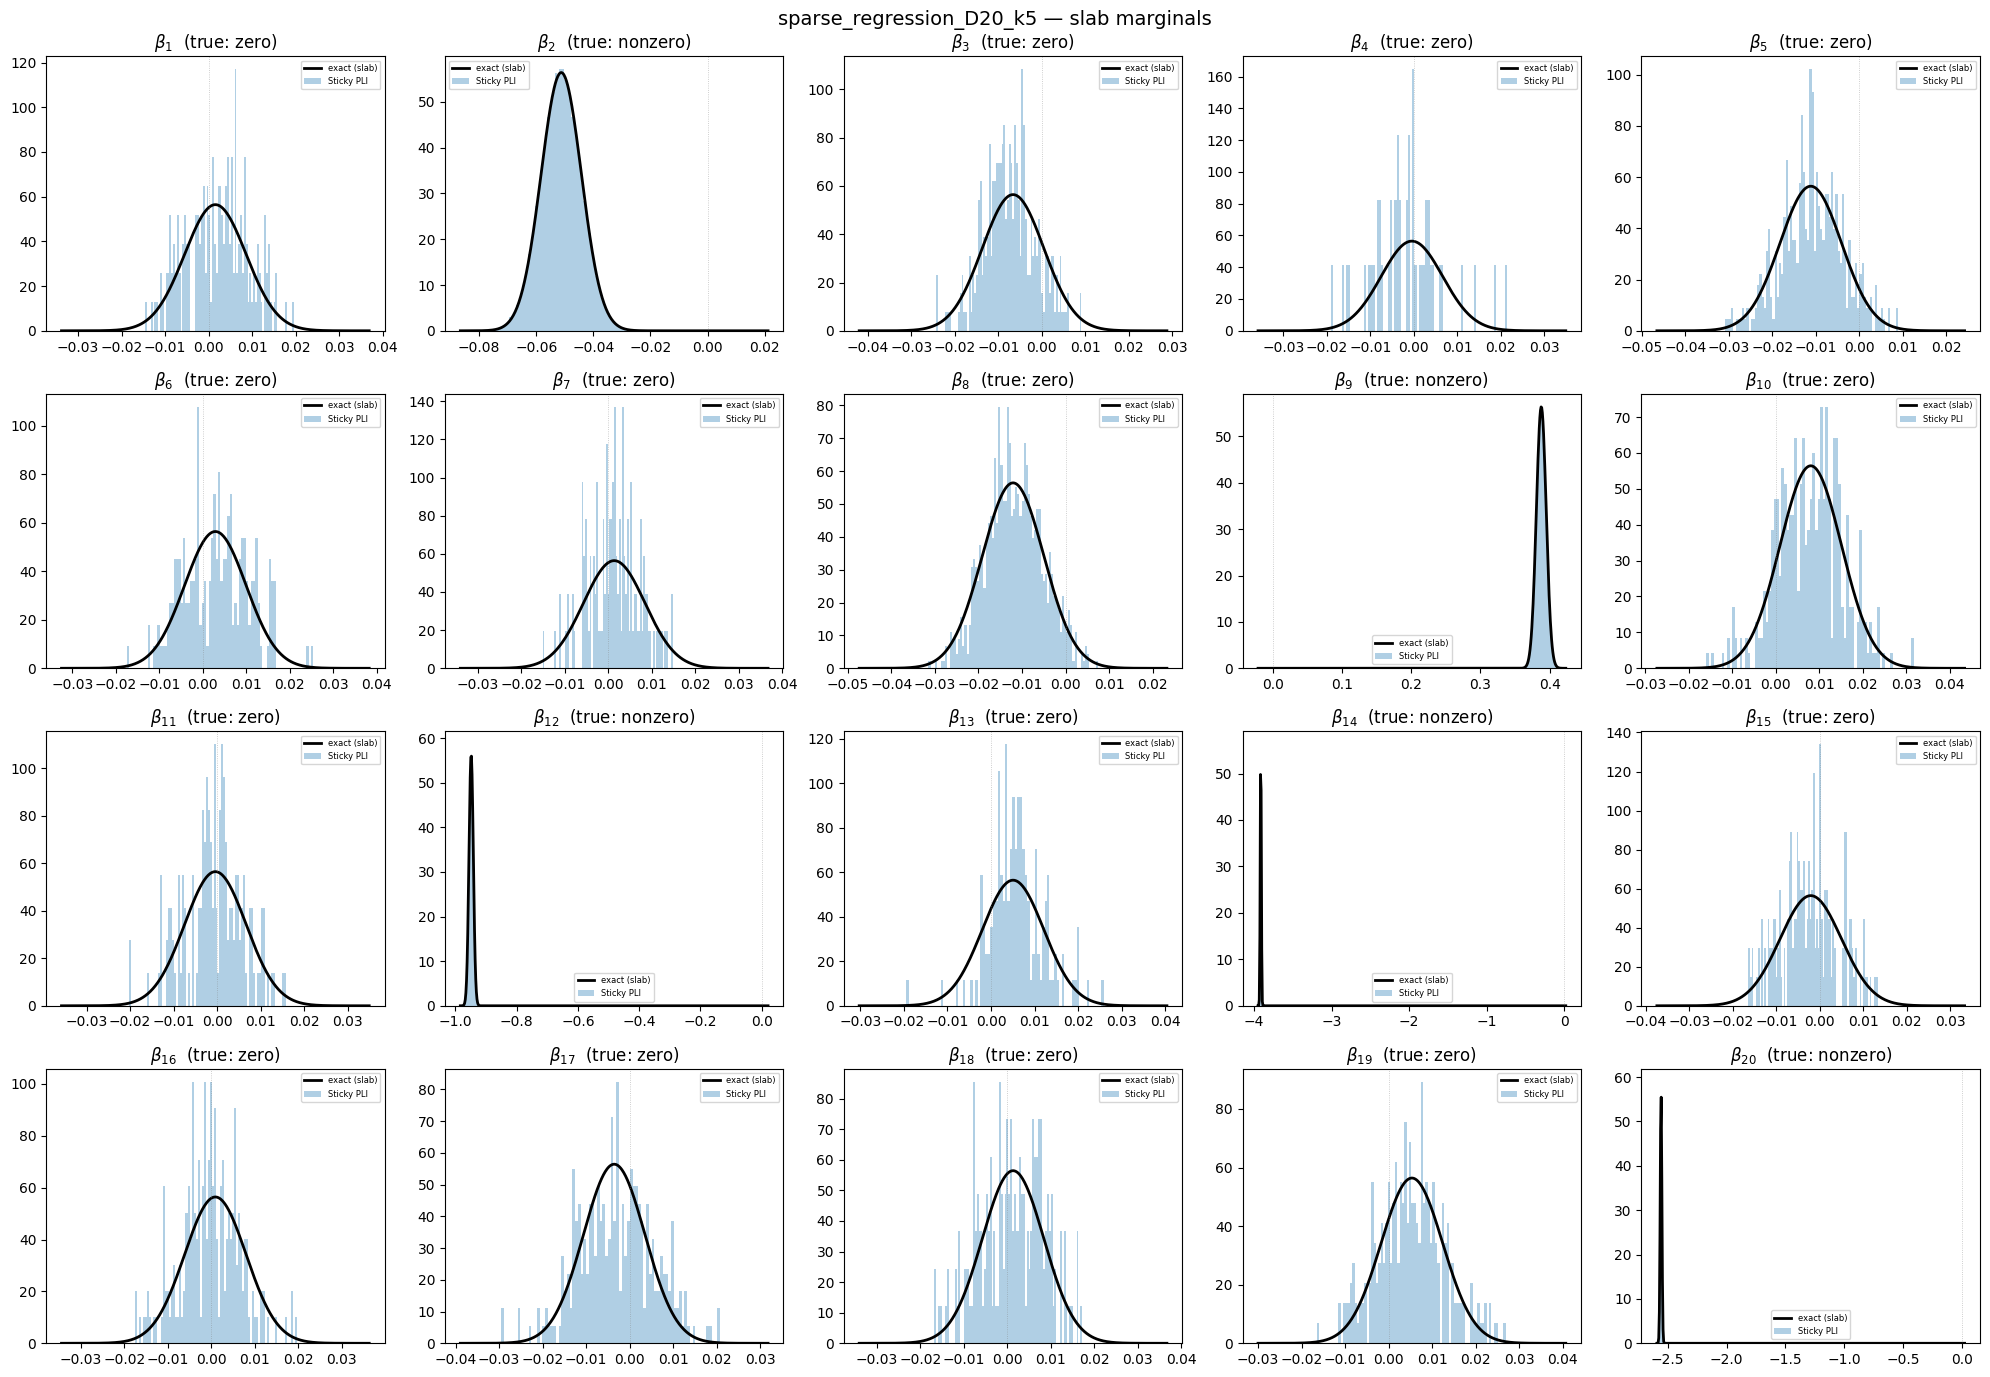

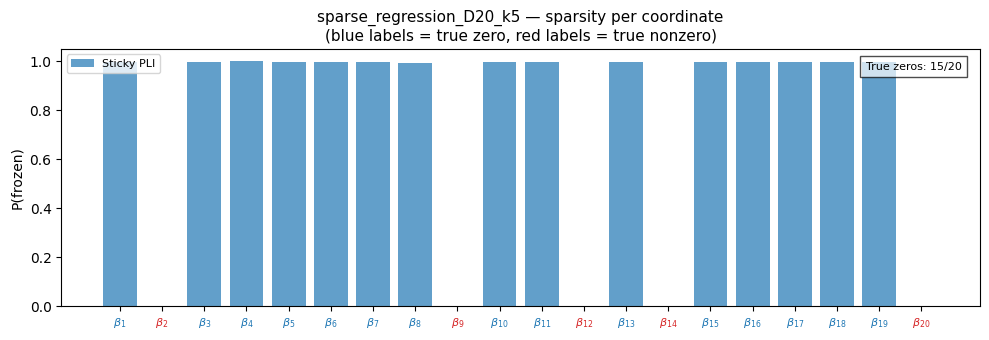

In [4]:
from sazz.models.sticky_smoke_test import make_sparse_regression
N_SKELETON = 100_000
N_RESAMPLE = 100_000
target_reg = make_sparse_regression(D=20, n_obs=200, noise_std=0.1)

# sampler_brent_reg = StickyAutomaticBoomerangSampler(
#     grad_target=target_reg.grad_target, D=target_reg.D,
#     kappa=0.1, thinning="brent", refresh_rate=0.1,
# )

# sampler_brent_reg.preprocess(x_ref=target_reg.x_ref, Sigma_inv=target_reg.Sigma_inv)
# result_brent_reg = sampler_brent_reg.sample(N=N_SKELETON)

# samples_brent_reg = resample_pdmp_path_sticky(
#     result_brent_reg["positions"].cpu().numpy(),
#     result_brent_reg["velocities"].cpu().numpy(),
#     result_brent_reg["times"].cpu().numpy(),
#     target_reg.x_ref.cpu().numpy(),
#     N_resample=N_RESAMPLE,
# )

sampler_pli_reg = StickyAutomaticBoomerangSampler(
    grad_target=target_reg.grad_target, D=target_reg.D,
    kappa=0.1, thinning="pli", refresh_rate=0.1,
)

sampler_pli_reg.preprocess(x_ref=target_reg.x_ref, Sigma_inv=target_reg.Sigma_inv)
result_pli_reg = sampler_pli_reg.sample(N=N_SKELETON)

samples_pli_reg = resample_pdmp_path_sticky(
    result_pli_reg["positions"].cpu().numpy(),
    result_pli_reg["velocities"].cpu().numpy(),
    result_pli_reg["times"].cpu().numpy(),
    target_reg.x_ref.cpu().numpy(),
    N_resample=N_RESAMPLE,
)


#plot_sticky_marginals(target_reg, {"Sticky Brent": samples_brent_reg, "Sticky PLI": samples_pli_reg})
plot_sticky_marginals(target_reg, {"Sticky PLI": samples_pli_reg})


In [5]:
#print_sparsity_summary(target_reg, {"Sticky Brent": samples_brent_reg, "Sticky PLI": samples_pli_reg})
print_sparsity_summary(target_reg, {"Sticky PLI": samples_pli_reg})


Sparsity summary: sparse_regression_D20_k5

  Sticky PLI:
    coord     beta_true     P(0)  status
    ----------------------------------------
    0            0.0000    0.998  zero
    1           -0.0504    0.000  NONZERO
    2            0.0000    0.997  zero
    3            0.0000    1.000  zero
    4            0.0000    0.995  zero
    5            0.0000    0.998  zero
    6            0.0000    0.999  zero
    7            0.0000    0.991  zero
    8            0.3835    0.000  NONZERO
    9            0.0000    0.996  zero
    10           0.0000    0.998  zero
    11          -0.9487    0.000  NONZERO
    12           0.0000    0.999  zero
    13          -3.9065    0.000  NONZERO
    14           0.0000    0.998  zero
    15           0.0000    0.998  zero
    16           0.0000    0.997  zero
    17           0.0000    0.998  zero
    18           0.0000    0.997  zero
    19          -2.5591    0.000  NONZERO

    Overall sparsity: 0.748


Sticky Boomerang: 100%|██████████| 100000/100000 [01:15<00:00, 1316.56skel/s, t=848418.720]



=== Sampler Diagnostics ===
Total gradient evals  : 499995
Grad evals / skeleton : 5.0
Mean sparsity (frac frozen): 0.215
Max simultaneous frozen    : 2 / 100000

=== Thinning ===
Accepted bounces : 0

=== Event breakdown ===
  freeze    :  7973 events, mean horizon=2.4704
  thaw      :  7971 events, mean horizon=8.7108
  refresh   : 84055 events, mean horizon=0.0000
  no_event  : 84055 events, mean horizon=9.0332

=== Timing ===
Mean wall-sec / iter : 0.000297
Total wall-sec       : 54.60

Simulation time reached: 848418.7197


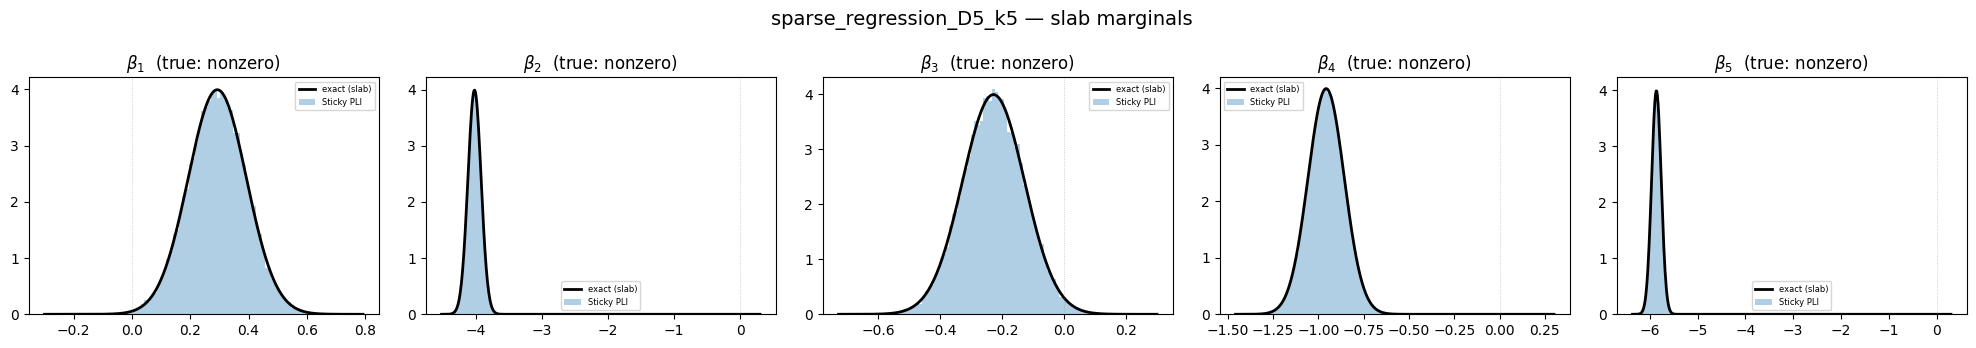

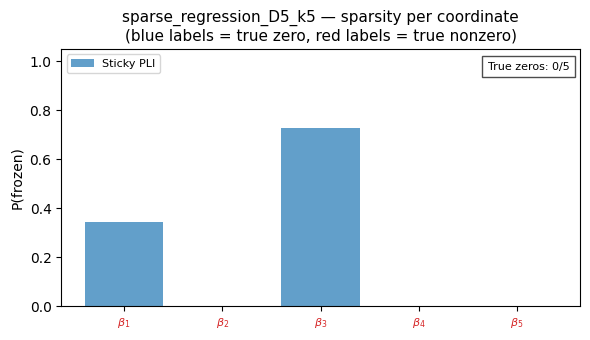

In [6]:
from sazz.models.sticky_smoke_test import make_laplace
N_SKELETON = 100_000
N_RESAMPLE = 100_000
target_laplace = make_sparse_regression(D=5)

# sampler_brent_laplace = StickyAutomaticBoomerangSampler(
#     grad_target=target_laplace.grad_target, D=target_laplace.D,
#     kappa=0.1, thinning="brent", refresh_rate=0.1,
# )

# sampler_brent_laplace.preprocess(x_ref=target_laplace.x_ref, Sigma_inv=target_laplace.Sigma_inv)
# result_brent_laplace = sampler_brent_laplace.sample(N=N_SKELETON)

# samples_brent_laplace = resample_pdmp_path_sticky(
#     result_brent_laplace["positions"].cpu().numpy(),
#     result_brent_laplace["velocities"].cpu().numpy(),
#     result_brent_laplace["times"].cpu().numpy(),
#     target_laplace.x_ref.cpu().numpy(),
#     N_resample=N_RESAMPLE,
# )

sampler_pli_laplace = StickyAutomaticBoomerangSampler(
    grad_target=target_laplace.grad_target, D=target_laplace.D,
    kappa=0.1, thinning="pli", refresh_rate=0.1,
)

sampler_pli_laplace.preprocess(x_ref=target_laplace.x_ref, Sigma_inv=target_laplace.Sigma_inv)
result_pli_laplace = sampler_pli_laplace.sample(N=N_SKELETON)

samples_pli_laplace = resample_pdmp_path_sticky(
    result_pli_laplace["positions"].cpu().numpy(),
    result_pli_laplace["velocities"].cpu().numpy(),
    result_pli_laplace["times"].cpu().numpy(),
    target_laplace.x_ref.cpu().numpy(),
    N_resample=N_RESAMPLE,
)


#plot_sticky_marginals(target_laplace, {"Sticky Brent": samples_brent_laplace, "Sticky PLI": samples_pli_laplace})
plot_sticky_marginals(target_laplace, {"Sticky PLI": samples_pli_laplace})


In [7]:
#print_sparsity_summary(target_laplace, {"Sticky Brent": samples_brent_laplace, "Sticky PLI": samples_pli_laplace})
print_sparsity_summary(target_laplace, {"Sticky PLI": samples_pli_laplace})


Sparsity summary: sparse_regression_D5_k5

  Sticky PLI:
    coord     beta_true     P(0)  status
    ----------------------------------------
    0            0.3835    0.345  NONZERO
    1           -3.9065    0.000  NONZERO
    2           -0.0504    0.727  NONZERO
    3           -0.9487    0.000  NONZERO
    4           -5.8531    0.000  NONZERO

    Overall sparsity: 0.214
